In [23]:
# system
from pathlib import Path
import pickle

# analysis
import numpy as np
import pandas as pd
from scipy import stats
import glob 
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings
import os
from datetime import datetime

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import patsy
from scipy.stats import pearsonr

from umap import UMAP
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
import scipy.ndimage
from datetime import datetime

from iblutil.numerical import bincount2D
from iblatlas.atlas import BrainRegions
from iblatlas.regions import BrainRegions
br = BrainRegions()

from one.api import ONE
one = ONE(mode='remote')

In [24]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

# Load data

In [25]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
lda = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')
lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut')
lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut18-06-2026')
# lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut19-06-2026')
# lda = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut19-06-2026')mouse_LDA_10_k_5_bins_cut
lda = lda.rename(columns={0: 'lda_1'})
lda = lda.rename(columns={1: 'lda_2'})

## Trial level info

In [26]:
save_path = prefix + 'representation_learning_variability/paper-individuality/4_mice/'
trials_df = pd.read_parquet(save_path+'all_trials_04-05-2026')

trials_df['log_reaction'] = np.log(trials_df['reaction'])
trials_session_df = trials_df.groupby(['session']).agg({'log_reaction': 'mean'}).reset_index()
trials_session_df.columns = ['session', 'mean_log_reaction']

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Age per session

In [5]:
mice = lda.mouse_name.unique()
dob = pd.DataFrame(columns=['mouse_name', 'dob'], index=range(len(mice)))
for s, mouse in enumerate(mice):
    subject_info = one.alyx.rest('subjects', 'read', id=mouse)
    date_of_birth = subject_info.get('birth_date')
    dob['mouse_name'][s] = mouse
    dob['dob'][s] = date_of_birth

/tmp/ipykernel_53919/4242811871.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dob['mouse_name'][s] = mouse
/tmp/ipykernel_53919/4242811871.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are settin

In [6]:

# Get the session date for each row in lda based on the eid
lda['session_date'] = pd.to_datetime('NaT')
for idx, row in lda.iterrows():
    eid = row['session']  # assuming lda has an 'eid' column
    try:
        session_info = one.alyx.rest('sessions', 'read', id=eid)
        session_date = session_info.get('start_time')
        lda.loc[idx, 'session_date'] = pd.to_datetime(session_date)
    except:
        pass

# Merge dob info into lda
lda = lda.merge(dob, on='mouse_name', how='left')

# Calculate age in days at the time of the session
lda['dob'] = pd.to_datetime(lda['dob'])
lda['age_days'] = (lda['session_date'] - lda['dob']).dt.days

## Load FFs

In [27]:
save_path = prefix + 'representation_learning_variability/paper-individuality/neural/'
filename = f'psths_fanofactor_per_neuron_all_regions_18-06-2026'
filename = f'psths_fanofactor_per_neuron_all_regions_25-06-2026'
summary_df = pd.read_parquet(filename)
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']
BRAIN_REGIONS = ['CA1', 'DG', 'MRN', 'CP', 'LP', 'CA3']  # ZI PO
# BRAIN_REGIONS = ['DG']
COSMOS_REGIONS = ['HPF']


In [28]:
# =====================================================================
# STEP 1: ISOLATE UNIQUE ACRONYMS ONLY (MASSIVE SPEEDUP)
# =====================================================================
unique_areas = summary_df['area'].dropna().unique()

# Generate high-level Cosmos mappings for all unique areas in a single vectorized batch
cosmos_mapped = br.acronym2acronym(unique_areas, mapping='Cosmos')
cosmos_dict = dict(zip(unique_areas, cosmos_mapped))

# =====================================================================
# STEP 2: MAP ONTOLOGY ANCESTORS ONCE PER UNIQUE ACRONYM
# =====================================================================
mapping_dict = {}

for area_acronym in unique_areas:
    try:
        # Query the underlying Allen Ontological tree for structural parents
        region_id = br.acronym2id(area_acronym)
        ancestor_acronyms = br.ancestors(ids=region_id)['acronym']
        
        # 1. Gather ALL Thalamic sub-nuclei (including PO, LP, RTN, etc.) into a single block
        if 'TH' in ancestor_acronyms or area_acronym in ['PO', 'LP']:
            mapping_dict[area_acronym] = 'Thalamus'
            
        # 2. Gather ALL Hippocampal formations (including CA1, CA2, CA3, DG, Subiculum) 
        elif 'HPF' in ancestor_acronyms or area_acronym in ['CA1', 'DG']:
            mapping_dict[area_acronym] = 'Hippocampus'
            
        # 3. Gather ALL Visual areas (including VISa, VISam, VISp, VISpm, RSP) 
        elif 'Isocortex' in ancestor_acronyms and any(vis in area_acronym for vis in ['VIS', 'RSP']):
            mapping_dict[area_acronym] = 'Visual Cortex'
            
        # 4. Handle other surrounding cortical networks caught on your probes
        elif 'Isocortex' in ancestor_acronyms:
            if any(mot in area_acronym for mot in ['MOp', 'MOs', 'MO']): 
                mapping_dict[area_acronym] = 'Motor Cortex'
            elif any(ss in area_acronym for ss in ['SSp', 'SSs', 'SS']): 
                mapping_dict[area_acronym] = 'Somatosensory Cortex'
            else:
                mapping_dict[area_acronym] = 'Other Cortex'
                
        # 5. Default back to the pre-computed high-level Cosmos parent (Midbrain, Hindbrain, etc.)
        else:
            mapping_dict[area_acronym] = cosmos_dict.get(area_acronym, 'Other')
            
    except Exception:
        # Fallback safeguard
        mapping_dict[area_acronym] = cosmos_dict.get(area_acronym, 'Unassigned')


def map_beryl_to_functional(df):
    """
    Map Beryl fine-grained brain regions to functional systems.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Beryl' column containing fine-grained regions
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with new 'Functional' column
    """
    df = df.copy()
    
    beryl_to_functional = {
        # Hippocampus
        'CA1': 'Hippocampus', 'CA3': 'Hippocampus', 'DG': 'Hippocampus',
        # Thalamus
        'LP': 'Thalamus', 'PO': 'Thalamus', 'VPM': 'Thalamus', 'ZI': 'Thalamus',
        # Cortex
        'ACA': 'Cortex', 'AI': 'Cortex', 'MO': 'Cortex', 'MOp': 'Cortex', 'MOs': 'Cortex',
        'ORB': 'Cortex', 'PL': 'Cortex', 'PTLp': 'Cortex', 'RSPd': 'Cortex',
        'SSp': 'Cortex', 'SSs': 'Cortex', 'VIS': 'Cortex',
        # Midbrain
        'MRN': 'Midbrain', 'APN': 'Midbrain', 'SCm': 'Midbrain',
        # Striatum
        'ACB': 'Striatum', 'CP': 'Striatum',
        # Other
        'BLA': 'Amygdala', 'BMA': 'Amygdala',
        'CLA': 'Claustrum', 'OLF': 'OlfactoryAreas',
    }
    
    df['Functional'] = df['area'].map(beryl_to_functional)
    return df

summary_df['functional_group'] = summary_df['area'].map(mapping_dict)


In [29]:
# Perform a direct vectorized string-to-string transformation
summary_df['beryl_acronym'] = br.acronym2acronym(
    summary_df['area'].values, 
    mapping='Beryl'
)
# Collapses your dataset into the 12 primary structural divisions of the brain
summary_df['cosmos_acronym'] = br.acronym2acronym(
    summary_df['area'].values, 
    mapping='Cosmos'
)
# Remap from raw acronyms directly to the Swanson nomenclature
summary_df['swanson_acronym'] = br.acronym2acronym(
    summary_df['area'].values, 
    mapping='Swanson'
)
print(len(summary_df['swanson_acronym'].unique()))

221


In [30]:
## Remove root
# summary_df = summary_df.loc[summary_df['area']!='root']


In [31]:
len(summary_df.loc[summary_df['area']!='root'])

34658

In [32]:
# Different binning
# lda['binned1_new'] = pd.cut(lda['lda_1'], bins=5)
# bin_type = 'binned1_new'
bin_type = 'binned1'

/tmp/ipykernel_22882/2820079762.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  averaged_by_session = merged_df.groupby([bin_type, 'session'])[timestep_cols].mean()
/tmp/ipykernel_22882/2820079762.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  averaged_by_bin = averaged_by_session.groupby([bin_type])[timestep_cols].mean()
/tmp/ipykernel_22882/2820079762.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stde

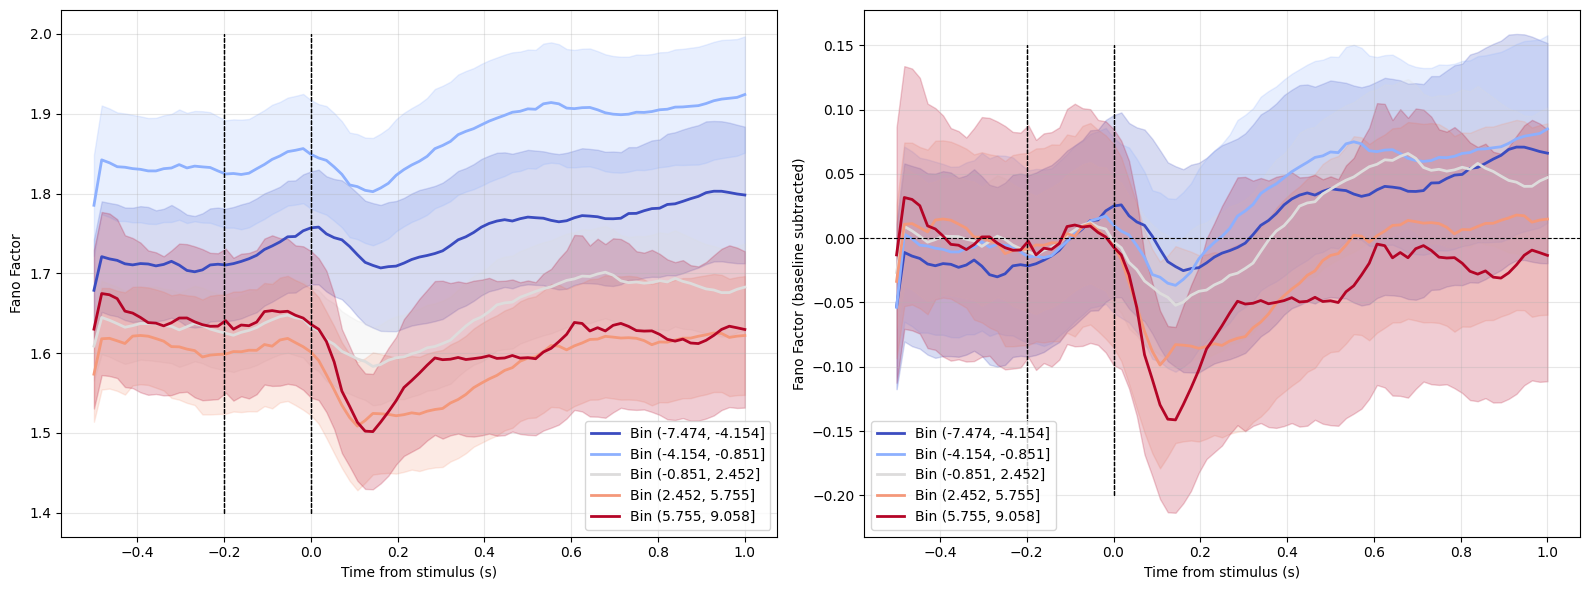

In [33]:
filtered = summary_df.loc[summary_df['area'].isin(BRAIN_REGIONS)]
filtered = summary_df.copy()

merged_df = filtered.merge(lda[[bin_type, 'session']], on='session')

# Assuming your timestep data is in columns (if not, we may need to reshape)
# Get the column names that represent timesteps (excluding metadata columns)
timestep_cols = [col for col in merged_df.columns if col not in ['session', bin_type, 'area', 'pid', 'beryl_acronym', 'functional_group',
                                                                 'cosmos_acronym', 'swanson_acronym', 'neuron_id', 'n_trials']]

# Group by binned1 and calculate mean and standard error across sessions for each timestep
averaged_by_session = merged_df.groupby([bin_type, 'session'])[timestep_cols].mean()
averaged_by_bin = averaged_by_session.groupby([bin_type])[timestep_cols].mean()
stderr_by_bin = averaged_by_session.groupby(bin_type)[timestep_cols].sem()  # standard error of the mean

# Sort bins by their values
sorted_bins = sorted(averaged_by_bin.index)

# Create the plot
# Create gradient color palette
colors = plt.cm.coolwarm(np.linspace(0, 1, len(sorted_bins)))
time_in_seconds = np.linspace(-0.5, 1.0, len(timestep_cols))

sigma = .002

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline window mask
baseline_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= -0.05)
baseline_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= -0.0)

for i, bin_value in enumerate(sorted_bins):
    mean_values = gaussian_filter1d(averaged_by_bin.loc[bin_value].values, sigma=sigma)
    error_values = gaussian_filter1d(stderr_by_bin.loc[bin_value].values, sigma=sigma)

    # Original
    axes[0].plot(time_in_seconds, mean_values,
                 label=f'Bin {bin_value}', linewidth=2, color=colors[i])
    axes[0].fill_between(time_in_seconds,
                         mean_values - error_values,
                         mean_values + error_values,
                         alpha=0.2, color=colors[i])

    # Baseline-subtracted
    baseline = np.mean(mean_values[baseline_mask])
    axes[1].plot(time_in_seconds, mean_values - baseline,
                 label=f'Bin {bin_value}', linewidth=2, color=colors[i])
    axes[1].fill_between(time_in_seconds,
                         (mean_values - baseline) - error_values,
                         (mean_values - baseline) + error_values,
                         alpha=0.2, color=colors[i])
    axes[1].vlines(-0.0, ymin=-0.2, ymax=0.15, color='k', linestyle='dashed', linewidth=0.8)
    axes[0].vlines(0, ymin=1.4, ymax=2, color='k', linestyle='dashed', linewidth=0.8)
    axes[0].vlines(-.2, ymin=1.4, ymax=2, color='k', linestyle='dashed', linewidth=0.8)
    axes[1].vlines(-0.2, ymin=-0.2, ymax=0.15, color='k', linestyle='dashed', linewidth=0.8)

for ax in axes:
    ax.set_xlabel('Time from stimulus (s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Fano Factor')
axes[1].set_ylabel('Fano Factor (baseline subtracted)')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle='--')

fig.tight_layout()
plt.show()

## LDA 1 effects

### on Fano Factor

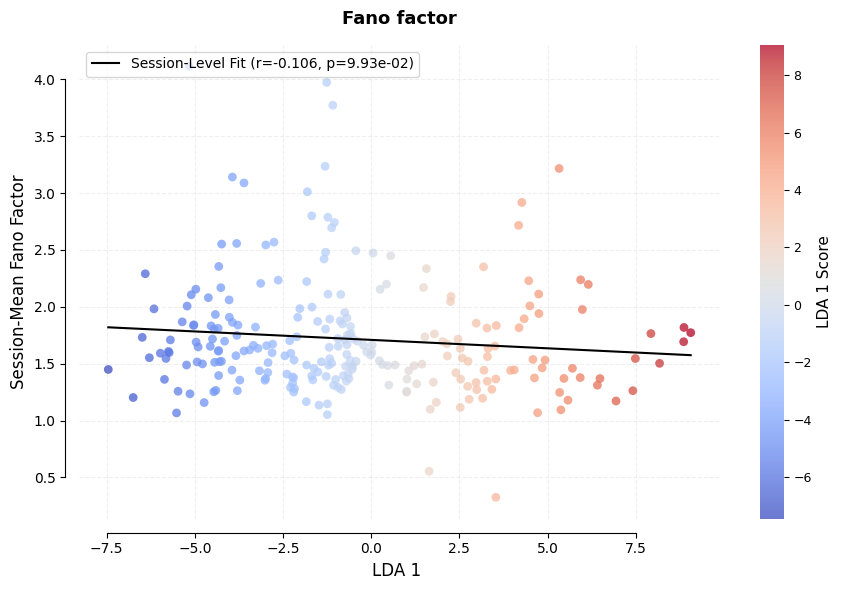

Total number of independent sessions plotted: 244


In [35]:
from scipy import stats

filtered = summary_df.loc[summary_df['area'].isin(BRAIN_REGIONS)]
filtered = summary_df.copy()
merged_df = filtered.merge(lda[[bin_type, 'session']], on='session')

# =====================================================================
# CONFIGURATION: SELECTION OF THE TIME WINDOW TO AVERAGE OVER
# =====================================================================
TIME_START = -0.2
TIME_END = 0.

# 1. Map your time_in_seconds array to your timestep columns
timestep_cols_arr = np.array(timestep_cols)
t_mask = (time_in_seconds >= TIME_START) & (time_in_seconds <= TIME_END)
selected_time_cols = timestep_cols_arr[t_mask]

# Ensure the continuous 'lda_1' values are available in the dataframe
if 'lda_1' not in merged_df.columns:
    processing_df = merged_df.merge(lda[['session', 'lda_1']], on='session')
else:
    processing_df = merged_df.copy()

# =====================================================================
# STEP 1: COMPUTE THE WINDOW MEAN FOR EACH RAW ROW
# =====================================================================
windowed_matrix = processing_df[selected_time_cols].values.astype(float)
processing_df['window_mean_ff'] = np.mean(windowed_matrix, axis=1)

# =====================================================================
# STEP 2: AVERAGE PER SESSION (COLLAPSE ALL SUB-UNITS PER RECORDING)
# =====================================================================
# We aggregate by session, averaging both the Fano Factor window mean 
# and the lda_1 score (which is already identical across rows of the same session)
session_df = processing_df.groupby('session')[['lda_1', 'window_mean_ff']].mean().reset_index()

# =====================================================================
# STEP 3: CONTINUOUS REGRESSION ON SESSION AVERAGES
# =====================================================================
x = session_df['lda_1'].values
y = session_df['window_mean_ff'].values

# Calculate linear regression metrics on collapsed session data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

# =====================================================================
# VISUALIZATION: SESSION-LEVEL GRADIENT SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

# Color code the session dots along the x-axis (lda_1) using the coolwarm gradient
sc = ax.scatter(
    x, y, 
    c=x, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=40,            # Increased dot size slightly since there are fewer dots (1 per session)
    edgecolors='none'
)

# Plot the linear regression line representing the session-level trend
ax.plot(
    x_fit, 
    y_fit, 
    color='black', 
    linewidth=1.5,
    label=f'Session-Level Fit (r={r_value:.3f}, p={p_value:.2e})'
)

# Add the colorbar mapping
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1 Score', fontsize=11)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

# Labeling and polish
ax.set_xlabel('LDA 1 ', fontsize=12)
ax.set_ylabel(f'Session-Mean Fano Factor', fontsize=12)
ax.set_title(f'Fano factor', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(fontsize=10, loc='upper left', frameon=True)

# Clean layout
sns.despine(ax=ax, offset=10, trim=True)
fig.tight_layout()
plt.show()

print(f"Total number of independent sessions plotted: {len(session_df)}")

In [36]:
import statsmodels.formula.api as smf
plot_df = processing_df.merge(trials_session_df[['session', 'mean_log_reaction']], on='session')
plot_df['functional_group'] = plot_df['area'].map(mapping_dict)

# Compute quench per session × area (no averaging across areas)
quench_list = []

for idx, row in plot_df.iterrows():

    quench_list.append({
        'session': row['session'],
        'area': row['functional_group'], # functional_group
        'mean_ff': row['window_mean_ff'],
        'reaction': row['mean_log_reaction']
    })

quench_df = pd.DataFrame(quench_list)
quench_df = quench_df.merge(lda[['session', 'lda_1']], on='session')

# --- Linear Mixed Models: random intercept per session ---
# 1) Quench ~ lda_1 + area + n_trials
md_quench = smf.mixedlm("mean_ff ~ lda_1*C(area)", quench_df, groups=quench_df["session"])  # "quench ~ lda_1 + C(area) + lda_1:C(area) + n_trials"
mdf_quench = md_quench.fit()
print("=" * 60)
print("MODEL 1: Fano factor ~ lda_1 + area  + reaction | (1|session)")
print("=" * 60)
print(mdf_quench.summary())

MODEL 1: Fano factor ~ lda_1 + area  + reaction | (1|session)
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        mean_ff     
No. Observations:         65374          Method:                    REML        
No. Groups:               244            Scale:                     2.1798      
Min. group size:          6              Log-Likelihood:            -118677.0193
Max. group size:          831            Converged:                 Yes         
Mean group size:          267.9                                                 
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              1.671    0.041 41.124 0.000  1.592  1.751
C(area)[T.CNU]                        -0.044    0.041 -1.077 0.281 -0

### on FF quench

In [19]:
from scipy.stats import linregress

# Filter by brain regions
filtered = summary_df.loc[summary_df['area'].isin(BRAIN_REGIONS)].copy()
filtered = summary_df.copy()
filtered = filtered.merge(lda[[bin_type, 'session']], on='session')

sigma = 1
t_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= 0.2)
t_window = time_in_seconds[t_mask]

# =====================================================================
# STEP 1: COMPUTE QUENCH PER NEURON INDIVIDUALLY
# =====================================================================
raw_matrix = filtered[timestep_cols].values.astype(float)
smoothed_matrix = gaussian_filter1d(raw_matrix, sigma=sigma, axis=1)

neuron_quenches = []
neuron_quench_times = []

for i in range(len(filtered)):
    ts_win = smoothed_matrix[i, t_mask]

    # Define search window around stimulus
    search_window_mask = (t_window >= -0.2) & (t_window <= 0.2)

    # Find peak in the window (highest point)
    peak_idx_local = np.argmax(ts_win[search_window_mask])
    i_peak = np.where(search_window_mask)[0][peak_idx_local]
    t_peak = t_window[i_peak]
    v_peak = ts_win[i_peak]

    # Find minimum in the window (lowest point)
    min_idx_local = np.argmin(ts_win[search_window_mask])
    i_min = np.where(search_window_mask)[0][min_idx_local]
    t_min = t_window[i_min]
    v_min = ts_win[i_min]

    if t_peak < t_min:
        # Classical Quench: peak first, then minimum
        quench_val = v_peak - v_min  # Positive for drops
        later_time = t_min
    else:
        # Anti-Quench: minimum first, then peak
        quench_val = v_min - v_peak  # Negative for increases
        later_time = t_peak

    neuron_quenches.append(quench_val)
    neuron_quench_times.append(later_time)

# Add computed metrics to dataframe
filtered['neuron_quench'] = neuron_quenches
filtered['neuron_quench_time'] = neuron_quench_times

# =====================================================================
# STEP 2: AGGREGATE TO SESSION LEVEL
# =====================================================================
session_avg = filtered.groupby('session')[['neuron_quench', 'neuron_quench_time']].mean().reset_index()

quench_df = session_avg.rename(columns={
    'neuron_quench': 'quench',
    'neuron_quench_time': 'quench_time'
})

quench_df = quench_df.merge(lda[['session', 'lda_1']], on='session')

print(f"✓ Quench magnitude computed for {len(quench_df)} sessions")
print(f"  Mean quench: {quench_df['quench'].mean():.4f}")
print(f"  Range: {quench_df['quench'].min():.4f} to {quench_df['quench'].max():.4f}")

✓ Quench magnitude computed for 244 sessions
  Mean quench: 0.0673
  Range: -1.1684 to 2.0242


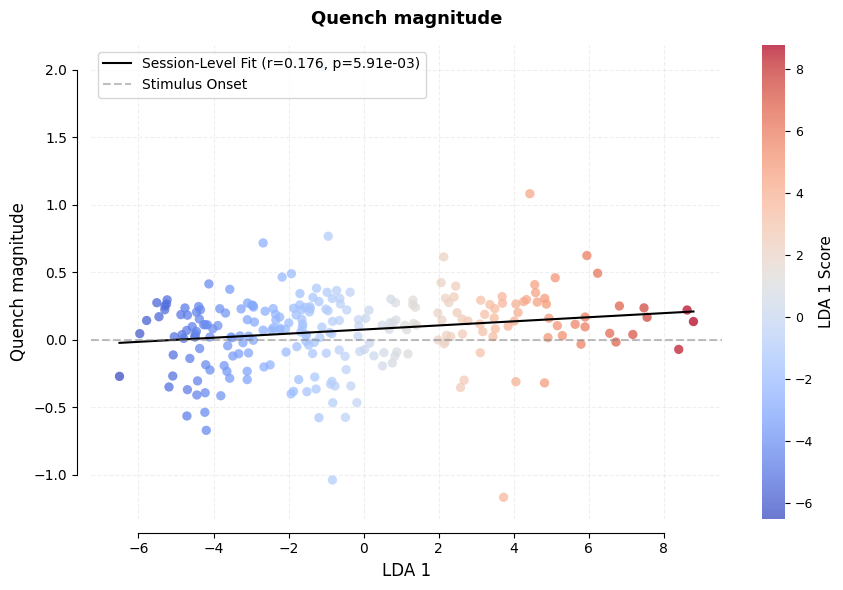

Total number of independent sessions plotted: 244


In [20]:
# =====================================================================
# GROUP BY SESSION AND AVERAGE NEURON TIMINGS
# =====================================================================
# # Calculate the mean onset latency across all recorded cells for each independent session
# session_df = filtered.groupby('session')['neuron_quench'].mean().reset_index()

# # Merge with your session-level LDA dataframe to pull in continuous lda_1 values
# quench_df = session_df.merge(lda[['session', 'lda_1']], on='session')

# =====================================================================
# VISUALIZATION: SESSION-LEVEL GRADIENT SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

x = quench_df['lda_1'].values
y = quench_df['quench'].values # This now reflects the mean neuron onset latency

slope, intercept, r, p, se = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

sc = ax.scatter(
    x, y, 
    c=x, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=45,            
    edgecolors='none'
)

ax.plot(
    x_fit, 
    y_fit, 
    color='black', 
    linewidth=1.5,
    label=f'Session-Level Fit (r={r:.3f}, p={p:.2e})'
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1 Score', fontsize=11)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

# Horizontal indicator for exact stimulus presentation onset
ax.axhline(0, color='grey', linestyle='--', alpha=0.5, label='Stimulus Onset')

ax.set_xlabel('LDA 1', fontsize=12)
ax.set_ylabel('Quench magnitude', fontsize=12)
ax.set_title('Quench magnitude', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(fontsize=10, loc='upper left', frameon=True)

sns.despine(ax=ax, offset=10, trim=True)
fig.tight_layout()
plt.show()

print(f"Total number of independent sessions plotted: {len(quench_df)}")

In [21]:
import statsmodels.formula.api as smf

use_df = filtered.merge(trials_session_df[['session', 'mean_log_reaction']], on='session')
# merged_df['functional_group'] = merged_df['area'].map(mapping_dict)

# use_df = use_df.merge(quench_df, on='session')
# Compute quench per session × area (no averaging across areas)
quench_list = []

for idx, row in use_df.iterrows():

    quench_list.append({
        'session': row['session'],
        'area': row['functional_group'],
        'quench': row['neuron_quench'],
        'reaction': row['mean_log_reaction']
    })

quench_df = pd.DataFrame(quench_list)
quench_df = quench_df.merge(lda[['session', 'lda_1']], on='session')

# --- Linear Mixed Models: random intercept per session ---
# 1) Quench ~ lda_1 + area + n_trials
md_quench = smf.mixedlm("quench ~ lda_1*C(area) + reaction", quench_df, groups=quench_df["session"])  # "quench ~ lda_1 + C(area) + lda_1:C(area) + n_trials"
mdf_quench = md_quench.fit()
print("=" * 60)
print("MODEL 1: Variability quench ~ lda_1 + reaction + area | (1|session)")
print("=" * 60)
print(mdf_quench.summary())

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


MODEL 1: Variability quench ~ lda_1 + reaction + area | (1|session)
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        quench      
No. Observations:         65374          Method:                    REML        
No. Groups:               244            Scale:                     1.8113      
Min. group size:          6              Log-Likelihood:            -112525.0212
Max. group size:          831            Converged:                 Yes         
Mean group size:          267.9                                                 
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.070    0.062 -1.134 0.257 -0.191  0.051
C(area)[T.CNU]                         0.044    0.037  1.216 0.

## Timing of quench onset

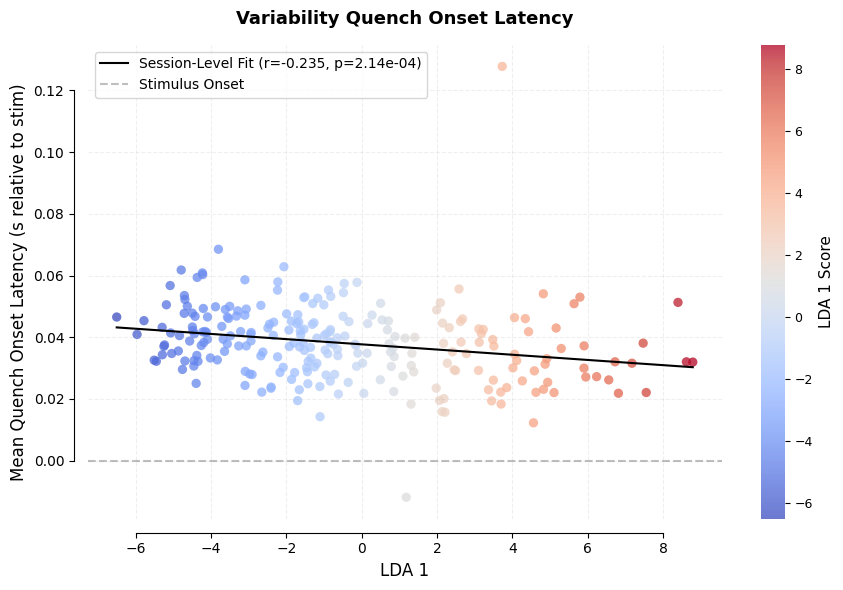

Total number of independent sessions plotted: 244


In [22]:
sigma = 1

filtered = summary_df.loc[summary_df['area'].isin(BRAIN_REGIONS)]
filtered = summary_df.copy()
merged_df = filtered.merge(lda[[bin_type, 'session']], on='session')

# Standard window for looking at the transition (-200ms to +200ms)
t_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= 0.2)
t_window = time_in_seconds[t_mask]

# Compute sampling rate (dt) to get an accurate derivative in per-second units
dt = time_in_seconds[1] - time_in_seconds[0] 

# Identify columns matching your sliding windows (e.g., 'time_0', 'time_1'...)
# Based on your prior snippet where you packaged them as record[f'time_{w_idx}'] = ff_val
time_cols = [col for col in merged_df.columns if col.startswith('time_')]

neuron_onset_records = []

# =====================================================================
# STEP 1: COMPUTE QUENCH ONSET TIMING FOR EACH NEURON INDEPENDENTLY
# =====================================================================
for idx, row in merged_df.iterrows():
    # Smooth the Fano Factor profile for this specific neuron
    ts = gaussian_filter1d(row[time_cols].values.astype(float), sigma=sigma)
    ts_win = ts[t_mask]
    
    # Isolate a narrow window around stimulus onset to look for a bump/peak (-50ms to +80ms)
    peak_search_mask = (t_window >= -0.05) & (t_window <= 0.08)
    ts_search = ts_win[peak_search_mask]
    t_search = t_window[peak_search_mask]
    
    # Lock onto the true starting point of the drop (the top of the bump, or pre-stim baseline)
    idx_peak_local = np.argmax(ts_search)
    t_peak = t_search[idx_peak_local]
    
    # Compute the first derivative (rate of change) across the window for this neuron
    derivative = np.gradient(ts_win, dt)
    
    # Find the maximum downward velocity (steepest part of the quench) *after* the peak
    after_peak_mask = (t_window >= t_peak) & (t_window <= 0.2)
    if not np.any(after_peak_mask):
        continue
        
    deriv_after_peak = derivative[after_peak_mask]
    min_deriv = np.min(deriv_after_peak) # Most negative value = fastest drop
    
    # Onset Threshold: When the drop hits 25% of its maximum downward speed
    onset_threshold = min_deriv * 0.25 
    
    # Find the first index after the peak where the drop crosses our speed threshold
    onset_idx_candidates = np.where((derivative < onset_threshold) & (t_window >= t_peak))[0]
    
    if len(onset_idx_candidates) > 0:
        quench_onset_time = t_window[onset_idx_candidates[0]]
    else:
        quench_onset_time = t_peak  # Fallback to peak if no threshold crossing is found

    neuron_onset_records.append({
        'session': row['session'],
        'area': row['area'],
        'neuron_id': row.get('neuron_id', idx), # Preserve unique identifier if present
        'quench_onset_time': quench_onset_time
    })

# Convert the per-neuron metrics into a dataframe
neuron_df = pd.DataFrame(neuron_onset_records)

# =====================================================================
# STEP 2: GROUP BY SESSION AND AVERAGE NEURON TIMINGS
# =====================================================================
# Calculate the mean onset latency across all recorded cells for each independent session
session_df = neuron_df.groupby('session')['quench_onset_time'].mean().reset_index()

# Merge with your session-level LDA dataframe to pull in continuous lda_1 values
quench_df = session_df.merge(lda[['session', 'lda_1']], on='session')

# =====================================================================
# VISUALIZATION: SESSION-LEVEL GRADIENT SCATTER PLOT
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 6))

x = quench_df['lda_1'].values
y = quench_df['quench_onset_time'].values # This now reflects the mean neuron onset latency

slope, intercept, r, p, se = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

sc = ax.scatter(
    x, y, 
    c=x, 
    cmap='coolwarm', 
    alpha=0.75, 
    s=45,            
    edgecolors='none'
)

ax.plot(
    x_fit, 
    y_fit, 
    color='black', 
    linewidth=1.5,
    label=f'Session-Level Fit (r={r:.3f}, p={p:.2e})'
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('LDA 1 Score', fontsize=11)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

# Horizontal indicator for exact stimulus presentation onset
ax.axhline(0, color='grey', linestyle='--', alpha=0.5, label='Stimulus Onset')

ax.set_xlabel('LDA 1', fontsize=12)
ax.set_ylabel('Mean Quench Onset Latency (s relative to stim)', fontsize=12)
ax.set_title('Variability Quench Onset Latency', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(fontsize=10, loc='upper left', frameon=True)

sns.despine(ax=ax, offset=10, trim=True)
fig.tight_layout()
plt.show()

print(f"Total number of independent sessions plotted: {len(quench_df)}")

## Model effect on quench onset

In [106]:
# Collapses your dataset into the 12 primary structural divisions of the brain
plot_df = neuron_df.merge(trials_session_df[['session', 'mean_log_reaction']], on='session')

plot_df['cosmos_acronym'] = br.acronym2acronym(
    plot_df['area'].values, 
    mapping='Cosmos'
)
plot_df['swanson_acronym'] = br.acronym2acronym(
    plot_df['area'].values, 
    mapping='Swanson'
)
plot_df['functional_group'] = plot_df['area'].map(mapping_dict)


# Compute quench per session × area (no averaging across areas)
quench_list = []

for idx, row in plot_df.iterrows():

    quench_list.append({
        'session': row['session'],
        'area': row['functional_group'],  # functional_group
        'quench_onset': row['quench_onset_time'],
        'reaction': row['mean_log_reaction']
    })

quench_df = pd.DataFrame(quench_list)
quench_df = quench_df.merge(lda[['session', 'lda_1']], on='session')

# --- Linear Mixed Models: random intercept per session ---
# 1) Quench ~ lda_1 + area + n_trials
md_quench = smf.mixedlm("quench_onset ~ lda_1 + lda_1*C(area)", quench_df, groups=quench_df["session"])  # "quench ~ lda_1 + C(area) + lda_1:C(area) + n_trials"
mdf_quench = md_quench.fit()
print("=" * 60)
print("MODEL 1: Quench onset ~ lda_1 + area + reaction | (1|session)")
print("=" * 60)
print(mdf_quench.summary())

MODEL 1: Quench onset ~ lda_1 + area + reaction | (1|session)
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        quench_onset
No. Observations:         34658          Method:                    REML        
No. Groups:               244            Scale:                     0.0041      
Min. group size:          1              Log-Likelihood:            45840.8215  
Max. group size:          515            Converged:                 Yes         
Mean group size:          142.0                                                 
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.050    0.001 34.896 0.000  0.047  0.053
C(area)[T.CNU]                        -0.007    0.002 -3.378 0.001 -0

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Plot coefficients

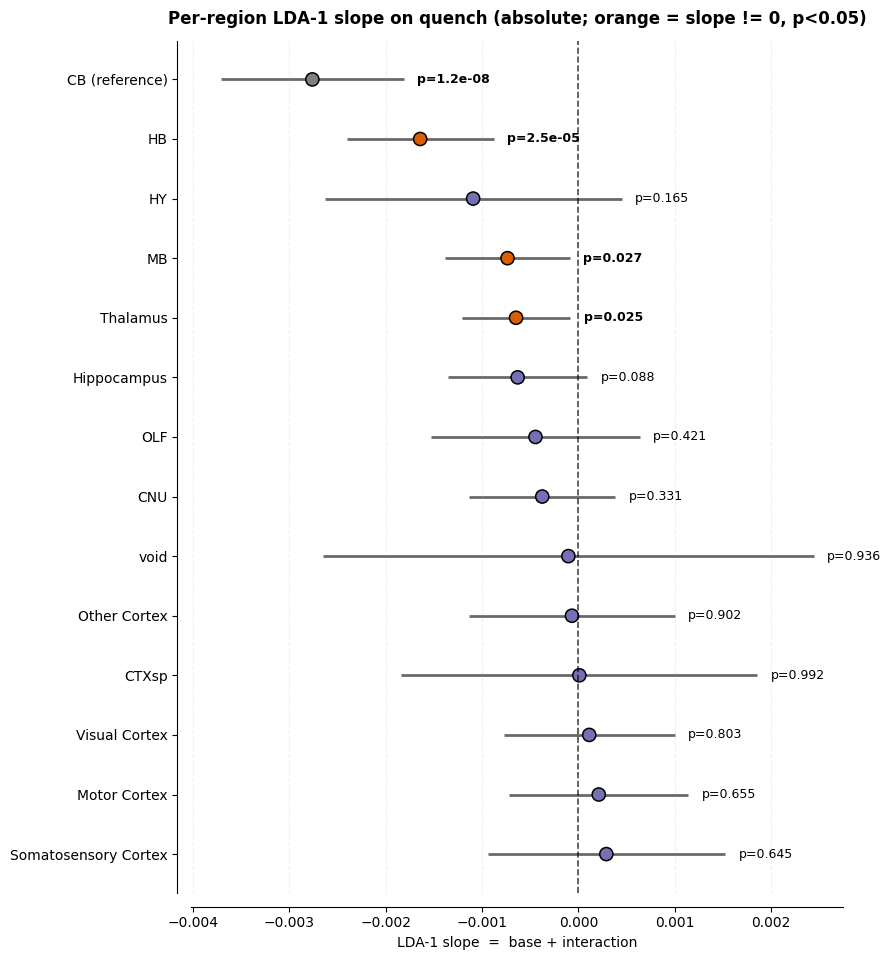

                area     slope      p_slope     diff   p_diff
      CB (reference) -0.002761 1.150076e-08 0.000000      NaN
                 CNU -0.000375 3.311680e-01 0.002386 0.000079
               CTXsp  0.000010 9.916558e-01 0.002771 0.008427
                  HB -0.001642 2.509983e-05 0.001119 0.033782
                  HY -0.001092 1.648028e-01 0.001669 0.068167
         Hippocampus -0.000630 8.809953e-02 0.002131 0.000303
                  MB -0.000736 2.660705e-02 0.002025 0.000243
        Motor Cortex  0.000212 6.546872e-01 0.002973 0.000008
                 OLF -0.000445 4.207286e-01 0.002316 0.001419
        Other Cortex -0.000067 9.022982e-01 0.002694 0.000178
Somatosensory Cortex  0.000290 6.449112e-01 0.003051 0.000092
            Thalamus -0.000647 2.451691e-02 0.002114 0.000093
       Visual Cortex  0.000113 8.033750e-01 0.002874 0.000006
                void -0.000104 9.362245e-01 0.002657 0.046888


In [101]:
from scipy import stats as sps

# =====================================================================
# Extract per-region LDA-1 slopes from an interaction model.
# For region R:  slope_R = beta_lda1 + beta_(lda1:R)   [reference region = beta_lda1]
# Standard error uses the FULL covariance of the linear combination
# (Var(a+b) = Var(a) + Var(b) + 2*Cov(a,b)) -- not the interaction SE alone.
# Returns both the absolute slope (test vs 0) and the interaction diff (vs reference).
# =====================================================================
def region_lda_slopes(model, all_areas, lda_term='lda_1'):
    fe = model.fe_params
    names = list(fe.index)
    cov = model.cov_params().loc[names, names].values
    idx = {n: i for i, n in enumerate(names)}
    inter = [n for n in names if n.startswith(lda_term + ':') and '[T.' in n]
    modeled = {n.split('[T.')[1].split(']')[0] for n in inter}
    ref = (set(map(str, all_areas)) - modeled)
    ref_name = list(ref)[0] if ref else 'reference'

    def combo(terms):
        L = np.zeros(len(names))
        for t in terms:
            L[idx[t]] = 1.0
        est = float(L @ fe.values)
        se = float(np.sqrt(L @ cov @ L))
        z = est / se if se > 0 else np.nan
        p = 2 * sps.norm.sf(abs(z)) if se > 0 else np.nan
        return est, se, est - 1.96 * se, est + 1.96 * se, p

    rows = []
    # reference region: slope = base lda_1
    est, se, lo, hi, p = combo([lda_term])
    rows.append(dict(area=f'{ref_name} (reference)', slope=est, slope_lo=lo, slope_hi=hi,
                     p_slope=p, diff=0.0, diff_lo=0.0, diff_hi=0.0, p_diff=np.nan))
    for t in inter:
        a = t.split('[T.')[1].split(']')[0]
        est, se, lo, hi, p = combo([lda_term, t])
        d = float(fe[t]); dse = float(model.bse[t])
        rows.append(dict(area=a, slope=est, slope_lo=lo, slope_hi=hi, p_slope=p,
                         diff=d, diff_lo=d - 1.96 * dse, diff_hi=d + 1.96 * dse,
                         p_diff=float(model.pvalues[t])))
    return pd.DataFrame(rows)


def forest_plot(df, value, lo, hi, pcol, title, xlabel):
    d = df.sort_values(value, ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(d) + 2))
    y = np.arange(len(d))
    colors = ['#7f7f7f' if 'reference' in a
              else ('#d95f02' if (pd.notna(p) and p < 0.05) else '#7570b3')
              for a, p in zip(d['area'], d[pcol])]
    ax.hlines(y, d[lo], d[hi], color='dimgray', lw=2, zorder=1)
    ax.scatter(d[value], y, c=colors, s=90, edgecolors='black', lw=1.1, zorder=2)
    ax.axvline(0, color='black', ls='--', lw=1.2, alpha=0.7)
    for i, row in d.iterrows():
        if pd.notna(row[pcol]):
            txt = f"p={row[pcol]:.1e}" if row[pcol] < 0.001 else f"p={row[pcol]:.3f}"
            ax.text(max(row[hi], row[value]) + abs(d[value]).max() * 0.05, i, txt,
                    va='center', fontsize=9,
                    fontweight='bold' if row[pcol] < 0.05 else 'normal')
    ax.set_yticks(y); ax.set_yticklabels(d['area'])
    ax.set_xlabel(xlabel); ax.set_title(title, fontweight='bold', pad=12)
    ax.grid(True, axis='x', alpha=0.2, ls='--')
    sns.despine(offset=10)
    plt.tight_layout(); plt.show()
    return d

# --- Absolute per-region slope of quench on LDA-1 (tested vs 0) ---
res = region_lda_slopes(mdf_quench, quench_df['area'].unique())
_ = forest_plot(res, 'slope', 'slope_lo', 'slope_hi', 'p_slope',
                'Per-region LDA-1 slope on quench (absolute; orange = slope != 0, p<0.05)',
                'LDA-1 slope  =  base + interaction')
print(res[['area', 'slope', 'p_slope', 'diff', 'p_diff']].to_string(index=False))

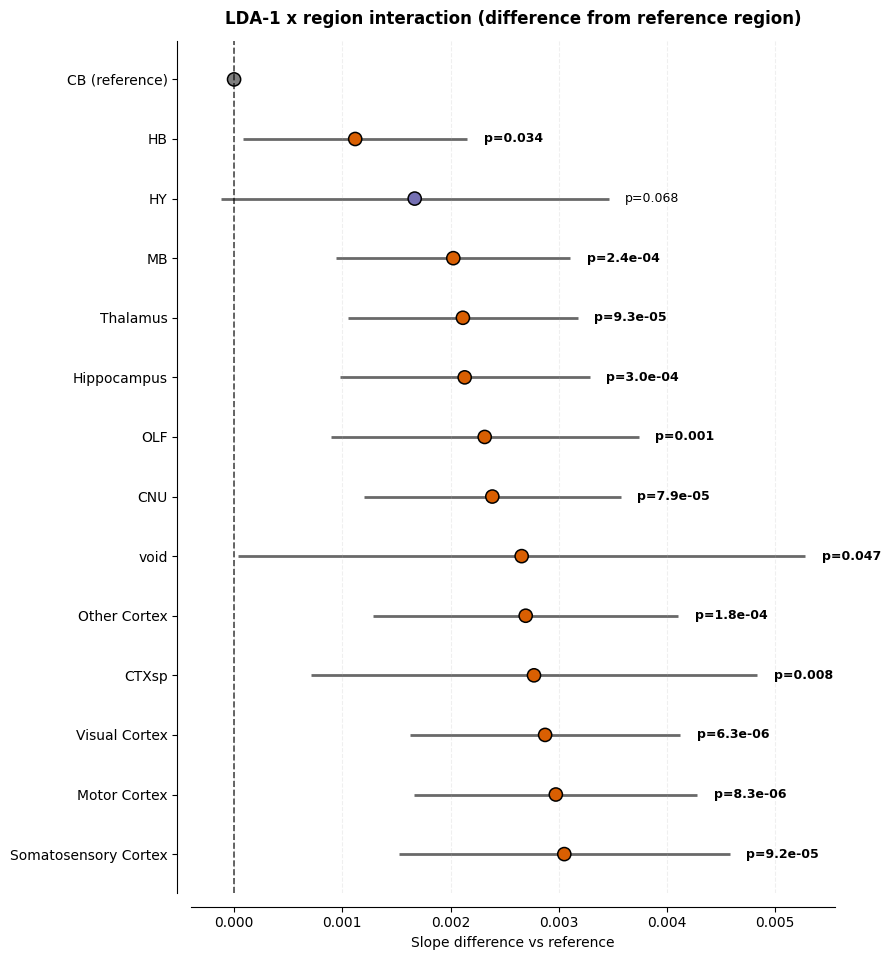

In [102]:
# =====================================================================
# Interaction coefficients = how each region's LDA-1 slope DIFFERS from the
# reference region (orange = significantly different FROM REFERENCE, not from 0).
# Compare with the plot above: a region can differ significantly from the
# reference yet still have an absolute slope near/below zero.
# =====================================================================
_ = forest_plot(res, 'diff', 'diff_lo', 'diff_hi', 'p_diff',
                'LDA-1 x region interaction (difference from reference region)',
                'Slope difference vs reference')